In [19]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
%matplotlib inline
%config InlineBackend.figure_formats = {'pdf', 'svg'}
from network import NetworkModel

In [18]:
N_AGENTS = 200
K = 6
P_REWIRE = 0.1
N_STEPS = 250
N_SEEDS = 10
EQUIL_WINDOW = 50
TAU_VALUES = [0.1, 0.3, 0.5, 1.0, 2.0]
LAM_VALUES = [1.0, 1.5, 2.0, 2.5, 3.0]
KAPPA_VALUES = [0.0, 0.2, 0.4, 0.6, 0.8]
FIXED_TAU = 0.5 # held constant when sweeping lam_mean
FIXED_LAM = 2.0 # held constant when sweeping tau
FIXED_KAPPA = 0.0 # held constant when sweeping tau or lam_mean

AGE_MEAN_VALUES = [16, 17, 19, 21, 23, 24]
FIXED_AGE_MEAN = 20.0


def run_many_seeds(param_overrides: dict, n_seeds: int = N_SEEDS) -> np.ndarray:
    all_histories = np.empty((n_seeds, N_STEPS + 1, 3))
    for seed in range(n_seeds):
        model = NetworkModel(
            n_agents=N_AGENTS,
            k=K,
            p_rewire=P_REWIRE,
            seed=seed,
            **param_overrides,
        )
        history = model.run(N_STEPS)
        all_histories[seed, :, 0] = history["susceptible"]
        all_histories[seed, :, 1] = history["current_drinkers"]
        all_histories[seed, :, 2] = history["former_drinkers"]
    return all_histories


def equilibrium_summary(all_histories: np.ndarray) -> dict[str, float]:
    windowed = all_histories[:, -EQUIL_WINDOW:, :]
    per_seed_mean = windowed.mean(axis=1)
    return {
        "D_mean": per_seed_mean[:, 1].mean(),
        "D_sd": per_seed_mean[:, 1].std(),
        "R_mean": per_seed_mean[:, 2].mean(),
        "R_sd": per_seed_mean[:, 2].std(),
    }


def plot_trajectories_by_param(param_name: str, param_values: list[float], fixed: dict):
    fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=True)
    colors = plt.cm.viridis(np.linspace(0, 0.9, len(param_values)))

    for value, color in zip(param_values, colors):
        overrides = dict(fixed)
        overrides[param_name] = value
        histories = run_many_seeds(overrides)

        mean = histories.mean(axis=0)# (n_steps+1, 3)
        sd = histories.std(axis=0)
        iterations = np.arange(N_STEPS + 1)

        axes[0].plot(iterations, mean[:, 1], color=color, label=f"{param_name}={value}")
        axes[0].fill_between(iterations, mean[:, 1] - sd[:, 1], mean[:, 1] + sd[:, 1], color=color, alpha=0.15)

        axes[1].plot(iterations, mean[:, 2], color=color, label=f"{param_name}={value}")
        axes[1].fill_between(iterations, mean[:, 2] - sd[:, 2], mean[:, 2] + sd[:, 2], color=color, alpha=0.15)

    axes[0].set_title(f"Current drinkers (D) vs iteration, varying {param_name}")
    axes[1].set_title(f"Former drinkers (R) vs iteration, varying {param_name}")
    for ax in axes:
        ax.set_xlabel("Iteration")
        ax.set_ylabel("Population fraction")
        ax.legend(fontsize=8)
    fig.suptitle(f"Sweep over {param_name} (n_seeds={N_SEEDS}, shaded = +/-1 sd across seeds)")
    fig.tight_layout()


def plot_equilibrium_sensitivity(param_name: str, param_values: list[float], fixed: dict):
    d_means, d_sds, r_means, r_sds = [], [], [], []
    for value in param_values:
        overrides = dict(fixed)
        overrides[param_name] = value
        histories = run_many_seeds(overrides)
        summary = equilibrium_summary(histories)
        d_means.append(summary["D_mean"])
        d_sds.append(summary["D_sd"])
        r_means.append(summary["R_mean"])
        r_sds.append(summary["R_sd"])

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.errorbar(param_values, d_means, yerr=d_sds, marker="o", capsize=4, label="Current drinkers (D)")
    ax.errorbar(param_values, r_means, yerr=r_sds, marker="s", capsize=4, label="Former drinkers (R)")
    ax.set_xlabel(param_name)
    ax.set_ylabel(f"Equilibrium population fraction (last {EQUIL_WINDOW} iterations)")
    ax.set_title(f"Long-run equilibrium vs {param_name} (n_seeds={N_SEEDS})")
    ax.legend()
    fig.tight_layout()



Sweep 1: tau (bounded rationality), lam_mean held fixed


KeyboardInterrupt: 

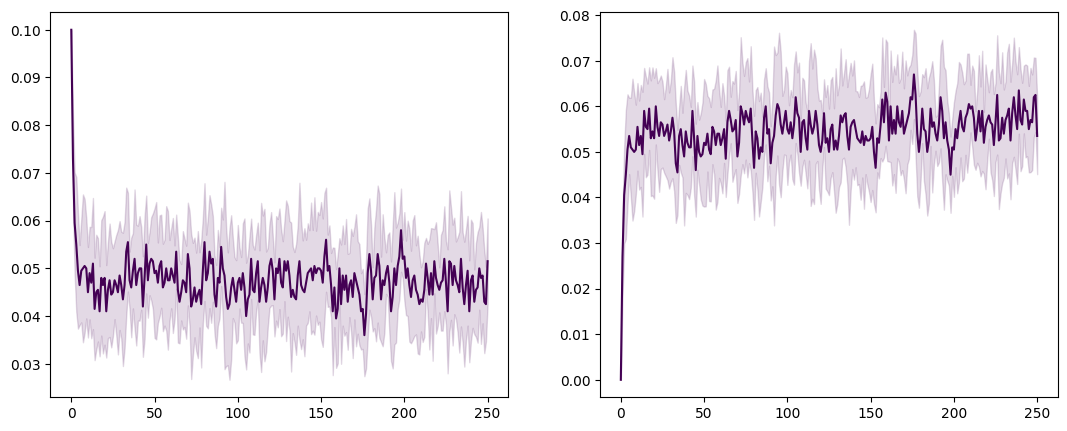

In [3]:

print("Sweep 1: tau (bounded rationality), lam_mean held fixed")
plot_trajectories_by_param("tau", TAU_VALUES, fixed={"lam_mean": FIXED_LAM, "kappa_mean": FIXED_KAPPA})
plot_equilibrium_sensitivity("tau", TAU_VALUES, fixed={"lam_mean": FIXED_LAM, "kappa_mean": FIXED_KAPPA})


print("Sweep 2: lam_mean (loss aversion), tau held fixed")
plot_trajectories_by_param("lam_mean", LAM_VALUES, fixed={"tau": FIXED_TAU, "kappa_mean": FIXED_KAPPA})
plot_equilibrium_sensitivity("lam_mean", LAM_VALUES, fixed={"tau": FIXED_TAU, "kappa_mean": FIXED_KAPPA})


print("Sweep 3: kappa_mean (risk aversion / curvature), tau and lam_mean held fixed")
plot_trajectories_by_param("kappa_mean", KAPPA_VALUES, fixed={"tau": FIXED_TAU, "lam_mean": FIXED_LAM})
plot_equilibrium_sensitivity("kappa_mean", KAPPA_VALUES, fixed={"tau": FIXED_TAU, "lam_mean": FIXED_LAM})

print("Sweep 4: age_mean, tau, lam_mean and kappa_mean held fixed")
plot_trajectories_by_param("age_mean", AGE_MEAN_VALUES, fixed={"tau": FIXED_TAU, "lam_mean": FIXED_LAM, "kappa_mean": FIXED_KAPPA})
plot_equilibrium_sensitivity("age_mean", AGE_MEAN_VALUES, fixed={"tau": FIXED_TAU, "lam_mean": FIXED_LAM, "kappa_mean": FIXED_KAPPA})

plt.show()

# OFAT

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from network import NetworkModel

# simulation settings
n_steps = 250
n_seeds = 10
absorption_threshold = 0.01  # S fraction below which absorption is called

# baseline configuration — all sweeps hold non-swept parameters at these values
baseline = {
    "n_agents":1000,
    "k":6,
    "p_rewire":0.1,
    "gamma":0.3,
    "rho":0.3,
    "tau":0.5,
    "lam_mean":2.0,
    "kappa_mean":0.0,
    "age_mean":20.0,
    "age_sd":2.0,
    "initial_drinker_frac":0.1,
}

# parameter ranges
tau_values = [0.05, 0.1, 0.3, 0.5, 1.0, 2.0] # finer resolution for tau at the low end (sharp transition observed there)
lam_values = [1.0, 1.5, 2.0, 2.5, 3.0, 4.0]
kappa_values = [0.0, 0.2, 0.4, 0.6, 0.8]
age_values = [16, 17, 19, 21, 23, 24]
k_values  = [2, 4, 6, 10, 14, 20]
p_rew_values= [0.0, 0.05, 0.1, 0.3, 0.5, 1.0]


def run_many_seeds(param_overrides: dict, n_seeds: int = n_seeds) -> np.ndarray:
    """Run across n_seeds seeds with param_overrides applied on top of baseline.
    Returns array of shape (n_seeds, n_steps+1, 3) — [S, D, R] fractions."""
    cfg = {**baseline, **param_overrides}
    histories = np.empty((n_seeds, n_steps + 1, 3))
    for seed in range(n_seeds):
        model = NetworkModel(seed=seed, **cfg)
        h = model.run(n_steps)
        histories[seed, :, 0] = h["susceptible"]
        histories[seed, :, 1] = h["current_drinkers"]
        histories[seed, :, 2] = h["former_drinkers"]
    return histories


def plot_trajectories(param_name: str, param_values: list, fixed: dict) -> None:
    """Full trajectory plot across all n_steps iterations.
    Three panels: S, D, R. Line = seed mean; shading = 95% CI across seeds."""
    fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharex=True)
    colors = plt.cm.viridis(np.linspace(0, 0.9, len(param_values)))
    iterations = np.arange(n_steps + 1)
    titles = ["Susceptible (S)", "Current drinkers (D)", "Former drinkers (R)"]

    for value, color in zip(param_values, colors):
        # merge fixed params with the single swept value
        overrides = {**fixed, param_name: value}
        h = run_many_seeds(overrides)

        mean = h.mean(axis=0)                              # shape: (n_steps+1, 3)
        ci   = 1.96 * h.std(axis=0) / np.sqrt(n_seeds)    # 95% CI across seeds

        for col_idx, (ax, title) in enumerate(zip(axes, titles)):
            ax.plot(iterations, mean[:, col_idx], color=color, label=f"{param_name}={value}")
            ax.fill_between(iterations, mean[:, col_idx] - ci[:, col_idx], mean[:, col_idx] + ci[:, col_idx], color=color, alpha=0.15,)
            ax.set_title(title)
            ax.set_xlabel("Iteration")
            ax.set_ylabel("Population fraction")
            ax.set_ylim(-0.02, 1.02)
            ax.legend(fontsize=7)

    fig.suptitle(
        f"OFAT — full trajectory sweep over {param_name} "
        f"(n={baseline['n_agents']}, n_seeds={n_seeds}, shaded = 95% CI)",fontsize=12,)
    fig.tight_layout()


if __name__ == "__main__":
    # sweep 1: tau (rationality temperature / bounded rationality)
    print("Sweep 1/6: tau")
    plot_trajectories("tau", tau_values, fixed={
        "lam_mean":baseline["lam_mean"],
        "kappa_mean": baseline["kappa_mean"],
        "age_mean":baseline["age_mean"],
        "k": baseline["k"],
        "p_rewire": baseline["p_rewire"],
    })

    # sweep 2: lam_mean (loss aversion)
    print("Sweep 2/6: lam_mean")
    plot_trajectories("lam_mean", lam_values, fixed={
        "tau": baseline["tau"],
        "kappa_mean":baseline["kappa_mean"],
        "age_mean": baseline["age_mean"],
        "k":  baseline["k"],
        "p_rewire":baseline["p_rewire"],
    })

    # sweep 3: kappa_mean (risk aversion / utility curvature)
    print("Sweep 3/6: kappa_mean")
    plot_trajectories("kappa_mean", kappa_values, fixed={
        "tau":baseline["tau"],
        "lam_mean":baseline["lam_mean"],
        "age_mean": baseline["age_mean"],
        "k": baseline["k"],
        "p_rewire": baseline["p_rewire"],
    })

    # sweep 4: age_mean — effect visible in trajectory shape, not long-run equilibrium
    # (S absorbs before the equilibrium window, so trajectory timing is the relevant output)
    print("Sweep 4/6: age_mean")
    plot_trajectories("age_mean", age_values, fixed={
        "tau": baseline["tau"],
        "lam_mean": baseline["lam_mean"],
        "kappa_mean": baseline["kappa_mean"],
        "k": baseline["k"],
        "p_rewire": baseline["p_rewire"],
    })

    # sweep 5: k (average network degree)
    print("Sweep 5/6: k")
    plot_trajectories("k", k_values, fixed={
        "tau": baseline["tau"],
        "lam_mean": baseline["lam_mean"],
        "kappa_mean": baseline["kappa_mean"],
        "age_mean": baseline["age_mean"],
        "p_rewire": baseline["p_rewire"],
    })

    # sweep 6: p_rewire (Watts-Strogatz rewiring — controls small-world-ness)
    print("Sweep 6/6: p_rewire")
    plot_trajectories("p_rewire", p_rew_values, fixed={
        "tau": baseline["tau"],
        "lam_mean": baseline["lam_mean"],
        "kappa_mean": baseline["kappa_mean"],
        "age_mean": baseline["age_mean"],
        "k": baseline["k"],
    })

    plt.show()

### Sensitivity Analysis: First and Total Order Sobol Indices

In [25]:
n_saltelli = 1024

params = [
    ("tau", 0.5, 2.0),
    ("lam_mean", 1.0, 3.0),
    ("kappa_mean", 0.0, 0.8),
    ("age_mean", 16, 24),
    ("n_agents", 200, 500)
]

K = len(params)

def run_single(param_dict: dict, seed:int) -> dict:
    n = int(round((param_dict.get("n_agents", 200))))
    model = NetworkModel(
        n_agents=n,
        k=K,
        p_rewire=P_REWIRE,
        seed=seed,
        tau=param_dict.get("tau", 0.5),
        lam_mean=param_dict.get("lam_mean", 2.0),
        kappa_mean=param_dict.get("kappa_mean", 0.0),
        age_mean=param_dict.get("age_mean", 13),
    )

    history = model.run(N_STEPS)
    equil_D = history["current_drinkers"][-EQUIL_WINDOW:].mean()
    return float(equil_D)

def evaluate_model(param_dict: dict) -> float:
    return np.mean([run_single(param_dict, seed) for seed in range(N_SEEDS)])

def saltelli_samples(n: int, k: int, bounds: list) -> np.ndarray: 
    """
    n: number of rows (samples)
    k: number of parameters
    bounds: parameter value bounds
    To create Saltelli samples, we first generate two matrices A and B of shape (n,k) with randomly drawn parameter values. Each column corresponds
    to one certain parameter. Next, for each column i, a new matrix A(i) is created, with all columns remaining the same from A, but the column i, which 
    now is taken from B. This is done for each column. In the end, the model runs (i + 2) * n number of times (as also the original A and B
    matrices must be run).
    """
    rng = np.random.default_rng(42)
    A = rng.random((n, k))
    B = rng.random((n, k))

    lo = np.array([b[1] for b in bounds])
    hi = np.array([b[2] for b in bounds])
    A = lo + A *(hi - lo)
    B = lo + B *(hi - lo)

    # Recombination matrices
    AB_list = []
    for i in range(k):
        AB_i = A.copy()
        AB_i[:, i] = B[:, i]
        AB_list.append(AB_i)

    return np.vstack([A, B] + AB_list)

def sobol_indices(Y: np.ndarray, n: int, k: int) -> tuple[np.ndarray, np.ndarray]:
    """
    Y: model outputs, ordered as Y_A, Y_B, Y_AB1, Y_AB2, ..., Y_ABk
    k: parameters 
    """

    # outputs generated with A and B (later AB_i)
    Y_A = Y[:n]
    Y_B = Y[n:2*n]

    # total variance
    var_A = np.var(Y_A, ddof=1)

    S_i = np.zeros(k) # first order, k parameters
    ST_i = np.zeros(k) # total order

    for i in range(k):
        Y_ABi = Y[2*n + i*n : 2*n + (i+1)*n]
 
        # Sobol indices estimators 
        # first-order: Saltelli estimator
        S_i[i]  = (np.mean(Y_B * (Y_ABi - Y_A))) / var_A
 
        # total-order: Jansen estimator
        ST_i[i] = np.mean((Y_A - Y_ABi) ** 2) / (2 * var_A)
 
    S_i  = np.clip(S_i,  0, 1)
    ST_i = np.clip(ST_i, 0, 1)
 
    return S_i, ST_i

def generate_sobol_indices():
    print("Generating Saltelli sample matrix...")
    X = saltelli_samples(n_saltelli, K, params)
    total_runs = X.shape[0]
    print("Total model evaluations to run:", total_runs)

    Y = np.zeros(total_runs)
    for idx in range(total_runs):
        param_dict = {params[j][0]: X[idx, j] for j in range(K)}
        Y[idx] = evaluate_model(param_dict)
        if (idx + 1) % max(1, total_runs // 20) == 0:
            pct = 100 * (idx + 1) / total_runs
            print(f"  {idx+1:4d}/{total_runs}  ({pct:.0f}%)  last Y={Y[idx]:.3f}")
    
    S_i, ST_i = sobol_indices(Y, n_saltelli, K)
    return S_i, ST_i, Y

In [26]:
# Plotting

# 1) Side by side: Sobol indices first and total order 
def plot_sobol_bars(S_i: np.ndarray, ST_i: np.ndarray):
    labels = [p[0] for p in params]
    order = np.argsort(S_i)[::-1]   
    sorted_labels = [labels[i] for i in order]
    sorted_Si = S_i[order]
    sorted_STi = ST_i[order]

    fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

    # First order
    bars1 = axes[0].barh(range(len(params)), sorted_Si,
                         color="#0D9488", alpha=0.85)
    axes[0].set_yticks(range(len(params)))
    axes[0].set_yticklabels(sorted_labels, fontsize=10)
    axes[0].set_xlabel("First-order Sobol index $S_i$", fontsize=10)
    axes[0].set_title("First-order $S_i$\n(direct effect only)", fontsize=10)
    axes[0].set_xlim(0, max(sorted_Si.max(), sorted_STi.max()) * 1.25 + 0.05)
    axes[0].xaxis.grid(True, linestyle="--", alpha=0.4)
    axes[0].set_axisbelow(True)
    axes[0].invert_yaxis()

    for bar, val in zip(bars1, sorted_Si):
        axes[0].text(val + 0.005, bar.get_y() + bar.get_height() / 2,
                     f"{val:.3f}", va="center", fontsize=9)

    # Total order
    bars2 = axes[1].barh(range(len(params)), sorted_STi,
                         color="#D97706", alpha=0.85)
    axes[1].set_yticks(range(len(params)))
    axes[1].set_yticklabels(sorted_labels, fontsize=10)
    axes[1].set_xlabel("Total-order Sobol index $S_{Ti}$", fontsize=10)
    axes[1].set_title("Total-order $S_{Ti}$\n(direct effect + all interactions)", fontsize=10)
    axes[1].set_xlim(0, max(sorted_Si.max(), sorted_STi.max()) * 1.25 + 0.05)
    axes[1].xaxis.grid(True, linestyle="--", alpha=0.4)
    axes[1].set_axisbelow(True)
    axes[1].invert_yaxis()

    for bar, val in zip(bars2, sorted_STi):
        axes[1].text(val + 0.005, bar.get_y() + bar.get_height() / 2,
                     f"{val:.3f}", va="center", fontsize=9)

    fig.suptitle(
        f"Sobol sensitivity indices — equilibrium drinker fraction\n"
        f"(N={n_saltelli} Saltelli samples, {N_SEEDS} seeds each)",
        fontsize=11)

    fig.text(
        0.5, 0.01,
        "Parameters with higher $S_{T_i}$ than $S_i$ are interaction-driven"
        " — small shifts may trigger systemic tipping points.",
        ha="center", fontsize=9,
        bbox=dict(boxstyle="round,pad=0.4", facecolor="white", alpha=0.85),
    )

    fig.tight_layout(rect=[0, 0.06, 1, 1])
    return fig

In [27]:
def plot_interaction_gaps(S_i: np.ndarray, ST_i: np.ndarray):
    grid = "#E4E4E0"
    zone_text = "#B84A2A"
    colors = ["#2563EB", "#DC2626", "#0D9488", "#D97706", "#7C3AED"]

    labels = [p[0] for p in params]
    fig, ax = plt.subplots(figsize=(10, 7))

    lim = max(S_i.max(), ST_i.max()) * 1.15 + 0.05

    ax.plot([0, lim], [0, lim], "k--", linewidth=0.8, alpha=0.5, label="No interaction")
    ax.fill_between([0, lim], [0, lim], [lim, lim], alpha=0.04, color="coral")
    ax.text(lim * 0.6, lim * 0.95, "interaction zone", fontsize=8, color=zone_text, alpha=0.7)

    ax.set_axisbelow(True)
    ax.grid(color=grid, linewidth=0.7, linestyle="-")
    for spine in ax.spines.values():
        spine.set_visible(False)
 
    colors = ["blue", "red", "teal", "orange", "purple"]
    
    for i, (label, si, sti) in enumerate(zip(labels, S_i, ST_i)):
        ax.scatter(si, sti, s=120, color=colors[i % len(colors)], zorder=5)
        ax.annotate(label, (si, sti), textcoords="offset points",
                    xytext=(8, 4), fontsize=8, color=colors[i % len(colors)])

        ax.plot([si, si], [si, sti], color=colors[i % len(colors)],
                linewidth=1, linestyle=":", alpha=0.6)
 
    ax.set_xlabel("First-order $S_i$", fontsize=10)
    ax.set_ylabel("Total-order $S_{Ti}$", fontsize=10)
    ax.set_title(
        "Interaction map: $S_i$ vs $S_{Ti}$\n"
        "Vertical gap = pure interaction contribution per parameter",
        fontsize=10,
    )
    ax.set_xlim(-0.02, lim)
    ax.set_ylim(-0.02, lim)
    ax.set_aspect("equal")
    ax.legend(fontsize=8)
 
    fig.tight_layout()
    return fig

In [28]:
S_i, ST_i, Y = generate_sobol_indices()

Generating Saltelli sample matrix...
Total model evaluations to run: 7168
   358/7168  (5%)  last Y=0.426
   716/7168  (10%)  last Y=0.368
  1074/7168  (15%)  last Y=0.390
  1432/7168  (20%)  last Y=0.187
  1790/7168  (25%)  last Y=0.475
  2148/7168  (30%)  last Y=0.344
  2506/7168  (35%)  last Y=0.052
  2864/7168  (40%)  last Y=0.264
  3222/7168  (45%)  last Y=0.351
  3580/7168  (50%)  last Y=0.377
  3938/7168  (55%)  last Y=0.337
  4296/7168  (60%)  last Y=0.421
  4654/7168  (65%)  last Y=0.293
  5012/7168  (70%)  last Y=0.288
  5370/7168  (75%)  last Y=0.394
  5728/7168  (80%)  last Y=0.450
  6086/7168  (85%)  last Y=0.462
  6444/7168  (90%)  last Y=0.317
  6802/7168  (95%)  last Y=0.402
  7160/7168  (100%)  last Y=0.420


Generating plots...
Generating Sobol indices bar plots...
Generating interaction gap plot...


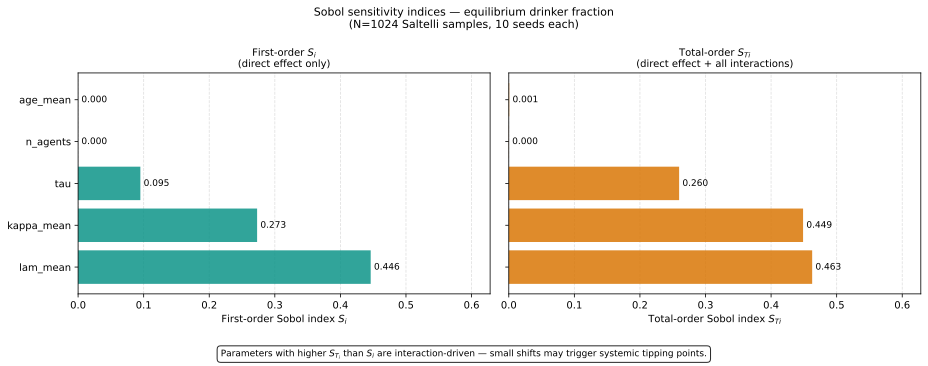

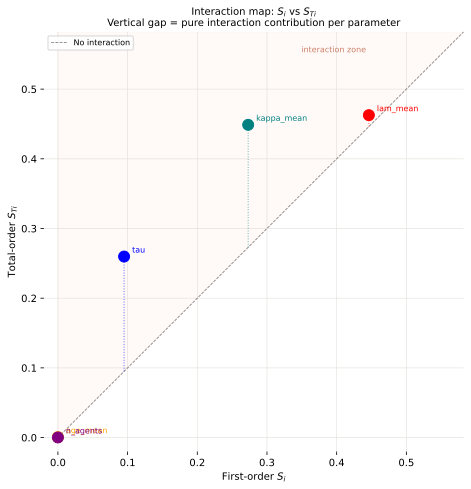

In [29]:
# Generate plots
print("Generating plots...")
print("Generating Sobol indices bar plots...")
fig1 = plot_sobol_bars(S_i, ST_i)
print("Generating interaction gap plot...")
fig2 = plot_interaction_gaps(S_i, ST_i)

**Understanding:** In this graph, we compare the contribution to the variance of each parameter individually vs. also with its interactions. Each point represents one parameter; if it lands on the diagonal line, it means $$S_i = S_{T_i},$$ which means, this parameter only has contributions on its own and not with interactions with other parameters. If the parameter is above the diagonal, it means it has more total influence than just its direct effect.